In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data/bank_transactions_data_2_augmented_clean_2.csv")
df.columns = df.columns.str.strip()

In [3]:
df.shape

(50000, 15)

In [4]:
df

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,TX000001,AC00128,14.09,4/11/2023 16:29,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21
1,TX000002,AC00455,376.24,6/27/2023 16:44,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91
2,TX000003,AC00019,126.29,7/10/2023 18:16,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35
3,TX000004,AC00070,184.50,5/5/2023 16:32,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06
4,TX000005,AC00411,13.45,10/16/2023 17:51,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,TX049996,AC00314,69.23,1/28/2025,Debit,Las Vegas,D000546,44.67.137.125,M097,Online,69,Doctor,69,1,6020.29
49996,TX049997,AC00370,514.53,1/23/2022,Debit,Houston,D000589,140.212.253.222,M061,ATM,46,Engineer,143,1,6371.51
49997,TX049998,AC00277,118.39,11/8/2022,Debit,Omaha,D000217,152.140.239.181,M029,Online,33,Doctor,296,1,749.34
49998,TX049999,AC00007,446.99,4/20/2025,Debit,Las Vegas,D000327,131.41.45.13,M082,ATM,58,Doctor,11,1,10915.11


In [5]:
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000
mean,297.872214,44.647600,118.965320,1.12684,5122.738301
std,292.818888,17.800293,70.000681,0.60936,3904.266887
min,0.240000,18.000000,10.000000,1.00000,101.250000
25%,82.897500,27.000000,63.000000,1.00000,1508.720000
50%,209.355000,45.000000,111.000000,1.00000,4735.410000
75%,409.625000,59.000000,161.000000,1.00000,7713.670000
max,2060.590000,80.000000,300.000000,5.00000,14977.990000


In [6]:
# Limpieza de datos

df.isnull().sum()
# df.dropna()

TransactionID          0
AccountID              0
TransactionAmount      0
TransactionDate        0
TransactionType        0
Location               0
DeviceID               0
IP Address             0
MerchantID             0
Channel                0
CustomerAge            0
CustomerOccupation     0
TransactionDuration    0
LoginAttempts          0
AccountBalance         0
dtype: int64

In [7]:
df.fillna(0, inplace=True)

In [8]:
df

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,TX000001,AC00128,14.09,4/11/2023 16:29,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21
1,TX000002,AC00455,376.24,6/27/2023 16:44,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91
2,TX000003,AC00019,126.29,7/10/2023 18:16,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35
3,TX000004,AC00070,184.50,5/5/2023 16:32,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06
4,TX000005,AC00411,13.45,10/16/2023 17:51,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,TX049996,AC00314,69.23,1/28/2025,Debit,Las Vegas,D000546,44.67.137.125,M097,Online,69,Doctor,69,1,6020.29
49996,TX049997,AC00370,514.53,1/23/2022,Debit,Houston,D000589,140.212.253.222,M061,ATM,46,Engineer,143,1,6371.51
49997,TX049998,AC00277,118.39,11/8/2022,Debit,Omaha,D000217,152.140.239.181,M029,Online,33,Doctor,296,1,749.34
49998,TX049999,AC00007,446.99,4/20/2025,Debit,Las Vegas,D000327,131.41.45.13,M082,ATM,58,Doctor,11,1,10915.11


In [9]:
df.columns

Index(['TransactionID', 'AccountID', 'TransactionAmount', 'TransactionDate',
       'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID',
       'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration',
       'LoginAttempts', 'AccountBalance'],
      dtype='object')

In [10]:
# Parseo de fechas y features temporales
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], format='mixed')
df['Month'] = df['TransactionDate'].dt.month
df['Hour'] = df['TransactionDate'].dt.hour
df['DayOfWeek'] = df['TransactionDate'].dt.dayofweek

In [11]:
df.groupby('CustomerOccupation')['TransactionAmount'].mean().sort_values(ascending=False)

CustomerOccupation
Student     313.154043
Retired     297.937759
Doctor      291.214523
Engineer    288.537243
Name: TransactionAmount, dtype: float64

In [12]:
df.groupby('CustomerOccupation')[['TransactionAmount', 'AccountBalance', 'LoginAttempts']].mean().sort_values(by='TransactionAmount', ascending=False)

,TransactionAmount,AccountBalance,LoginAttempts
CustomerOccupation,,,
Student,313.154043,1565.708390,1.111953
Retired,297.937759,4537.654897,1.134265
Doctor,291.214523,9003.504517,1.140642
Engineer,288.537243,5489.809499,1.121447


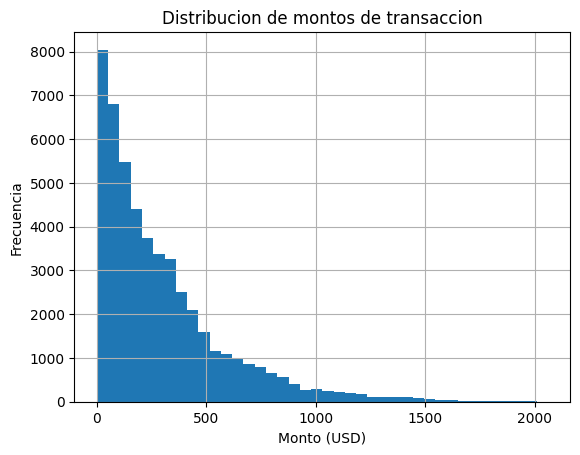

In [13]:
df['TransactionAmount'].hist(bins=40)

plt.title('Distribucion de montos de transaccion')
plt.xlabel('Monto (USD)')
plt.ylabel('Frecuencia')
plt.show()

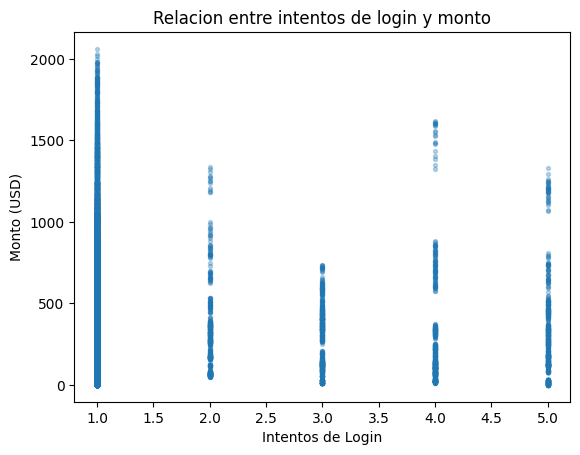

In [14]:
plt.scatter(df['LoginAttempts'], df['TransactionAmount'], alpha=0.3, s=8)

plt.title('Relacion entre intentos de login y monto')
plt.xlabel('Intentos de Login')
plt.ylabel('Monto (USD)')
plt.show()

In [15]:
df.groupby(['Channel', 'TransactionType'])['TransactionAmount'].mean().sort_values(ascending=False)

Channel  TransactionType
Branch   Credit             315.831136
ATM      Debit              303.163494
         Credit             301.901804
Online   Debit              300.664690
         Credit             294.641350
Branch   Debit              282.172365
Name: TransactionAmount, dtype: float64

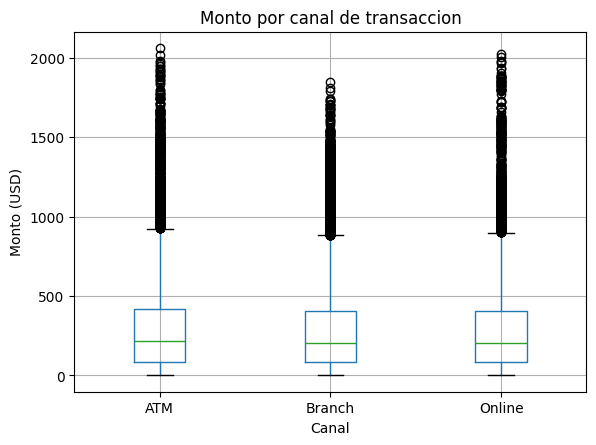

In [16]:
df.boxplot(column='TransactionAmount', by='Channel')

plt.title('Monto por canal de transaccion')
plt.suptitle('')
plt.xlabel('Canal')
plt.ylabel('Monto (USD)')
plt.show()

In [17]:
top_cities = df.groupby('Location')['TransactionAmount'].sum().sort_values(ascending=False).head(10)
top_cities

Location
Austin           453508.80
Memphis          445646.01
Oklahoma City    444559.54
San Antonio      423005.49
Fort Worth       422279.87
Jacksonville     411470.80
Phoenix          410725.84
Tucson           401159.06
Detroit          396371.02
Philadelphia     395031.93
Name: TransactionAmount, dtype: float64

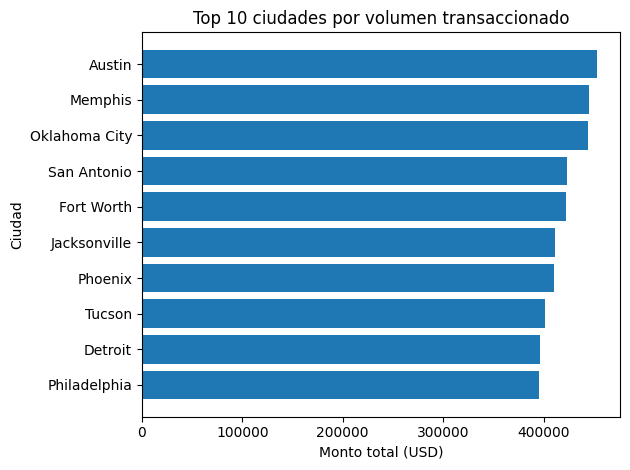

In [18]:
plt.barh(top_cities.index[::-1], top_cities.values[::-1])

plt.title('Top 10 ciudades por volumen transaccionado')
plt.xlabel('Monto total (USD)')
plt.ylabel('Ciudad')
plt.tight_layout()
plt.show()

In [19]:
import seaborn as sns

corr = df[['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'LoginAttempts', 'AccountBalance']].corr()

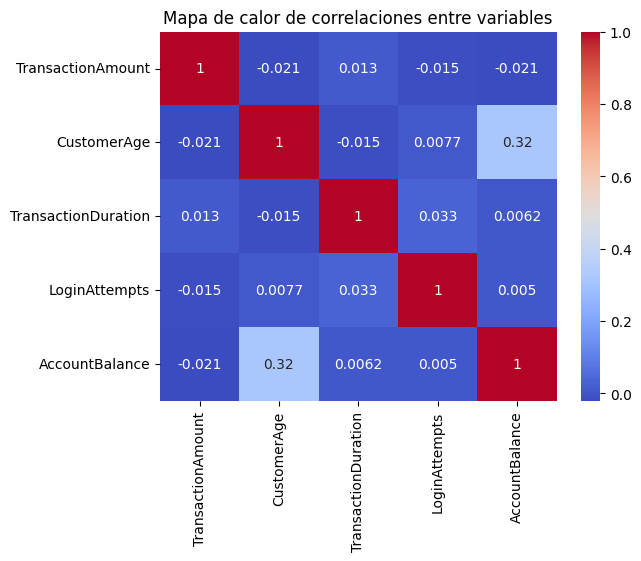

In [20]:
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Mapa de calor de correlaciones entre variables')
plt.show()

In [21]:
# Actividad por hora del dia
hour_cnt = df.groupby('Hour').size()
hour_cnt

Hour
0     47488
16     1316
17      819
18      377
dtype: int64

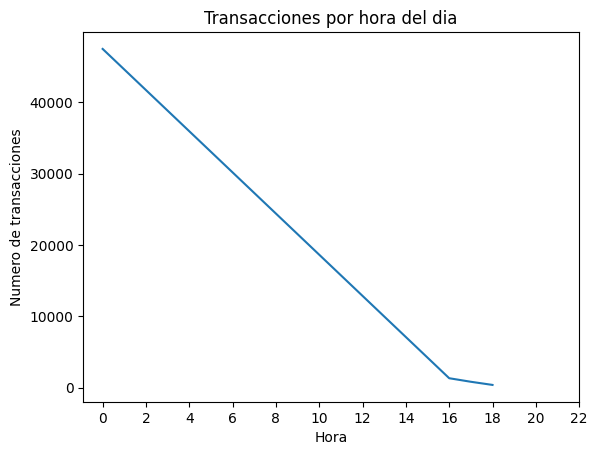

In [22]:
hour_cnt.plot()
plt.title('Transacciones por hora del dia')
plt.xlabel('Hora')
plt.ylabel('Numero de transacciones')
plt.xticks(range(0, 24, 2))
plt.show()

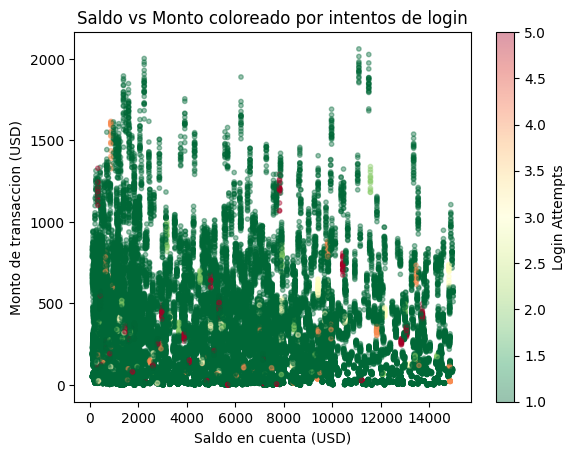

In [23]:
plt.scatter(
    df['AccountBalance'],
    df['TransactionAmount'],
    c=df['LoginAttempts'],
    cmap='RdYlGn_r',
    alpha=0.4,
    s=10
)
plt.colorbar(label='Login Attempts')
plt.title('Saldo vs Monto coloreado por intentos de login')
plt.xlabel('Saldo en cuenta (USD)')
plt.ylabel('Monto de transaccion (USD)')
plt.show()

In [24]:
# Guardar dataset limpio
df.to_csv('data/bank_transactions_clean.csv', index=False)
print('Dataset limpio guardado')

Dataset limpio guardado
